# 01 — Exploratory Data Analysis

This notebook loads the pre-computed feature windows, inspects their structure, checks data quality, and visualises class balance and feature distributions.
All plots are saved to `results/exploration/`.

## 1. Load Data

We load the pickled feature DataFrame generated by `scripts/feature_formation_from_dataset.py`.
Each row represents one 512-sample sliding window (511-sample step) extracted from the raw eye-tracking signal.

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

RESULTS = Path('../results/exploration')
RESULTS.mkdir(exist_ok=True)

with open('../data/features/features_512_511.pkl', 'rb') as f:
    df = pickle.load(f)

print('Loaded successfully.')

Loaded successfully.


## 2. Basic Inspection

Check the overall shape, column names, and the first few rows to confirm the data looks as expected.

In [2]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (347196, 18)

Columns: ['participant', 'id', 'window_index', 'sample_start', 'sample_end', 'label', 'vm_load', 'va_load', 'load_detection_label', 'load_type_label', 'ipas', 'lhipas', 'fixation_nums', 'fixation_durations', 'blink_rate', 'saccade_speeds', 'saccade_peak_speeds', 'diameter']


,participant,id,window_index,sample_start,sample_end,label,vm_load,va_load,load_detection_label,load_type_label,ipas,lhipas,fixation_nums,fixation_durations,blink_rate,saccade_speeds,saccade_peak_speeds,diameter
0,p1,1,0,0,511,1,1,0,1,0,0.001953,0.058594,427,1050.925059,0.509766,4698.978508,18469.574982,"[2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.2..."
1,p1,1,1,1,512,1,1,0,1,0,0.005859,0.060547,426,1052.962441,0.509766,4698.978508,18469.574982,"[2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.2..."
2,p1,1,2,2,513,1,1,0,1,0,0.001953,0.066406,425,1055.009412,0.509766,4698.978508,18469.574982,"[2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.2..."
3,p1,1,3,3,514,1,1,0,1,0,0.007812,0.062500,424,1057.066038,0.509766,4698.978508,18469.574982,"[2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.2..."
4,p1,1,4,4,515,1,1,0,1,0,0.001953,0.060547,423,1059.132388,0.509766,4698.978508,18469.574982,"[2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.25, 2.2..."


## 3. Missing / NaN Values

Any NaN values in feature columns would require imputation or removal before modelling.
We check every column here.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(summary[summary['missing_count'] > 0] if missing.any() else 'No missing values found.')
summary

No missing values found.


,missing_count,missing_%
participant,0,0.0
id,0,0.0
window_index,0,0.0
sample_start,0,0.0
sample_end,0,0.0
label,0,0.0
vm_load,0,0.0
va_load,0,0.0
load_detection_label,0,0.0
load_type_label,0,0.0


## 4. Class Balance — All 7 States (0–6)

The `label` column encodes cognitive-load states:
- **0** — Rest  
- **1–3** — Working Memory (WM) tasks at increasing difficulty  
- **4–6** — Visual Attention (VA) tasks at increasing difficulty  

A large imbalance between states could bias a classifier and would need to be addressed (e.g. via class weights or resampling).

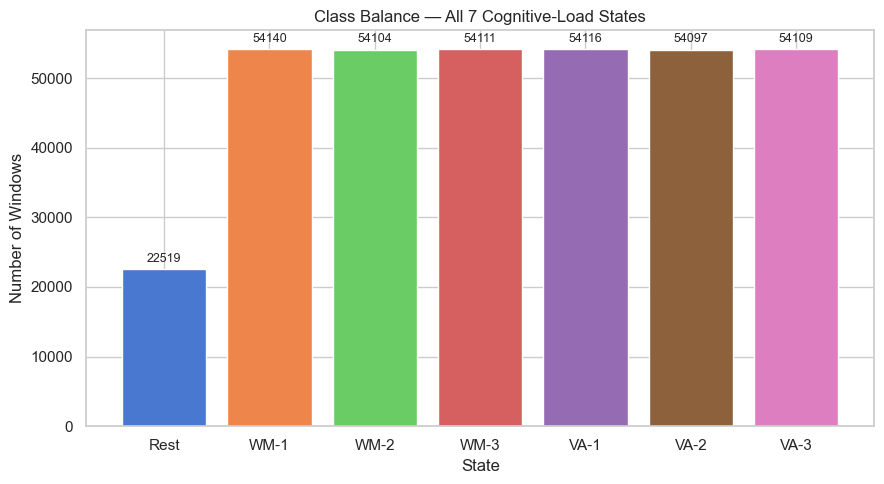

Saved: results/exploration/class_balance_all_states.png


In [4]:
state_labels = {
    0: 'Rest',
    1: 'WM-1', 2: 'WM-2', 3: 'WM-3',
    4: 'VA-1', 5: 'VA-2', 6: 'VA-3'
}

counts = df['label'].value_counts().sort_index()
labels = [state_labels[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('muted', len(counts)))
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('State')
ax.set_ylabel('Number of Windows')
ax.set_title('Class Balance — All 7 Cognitive-Load States')
plt.tight_layout()
plt.savefig(RESULTS / 'class_balance_all_states.png', dpi=150)
plt.show()
print('Saved: results/exploration/class_balance_all_states.png')

## 5. Class Balance — Binary Task Splits

Two common binary formulations are used in cognitive-load research:

1. **Rest vs Load** — can the system detect *any* cognitive load?  
2. **WM vs VA** (excluding rest) — can the system distinguish the *type* of load?

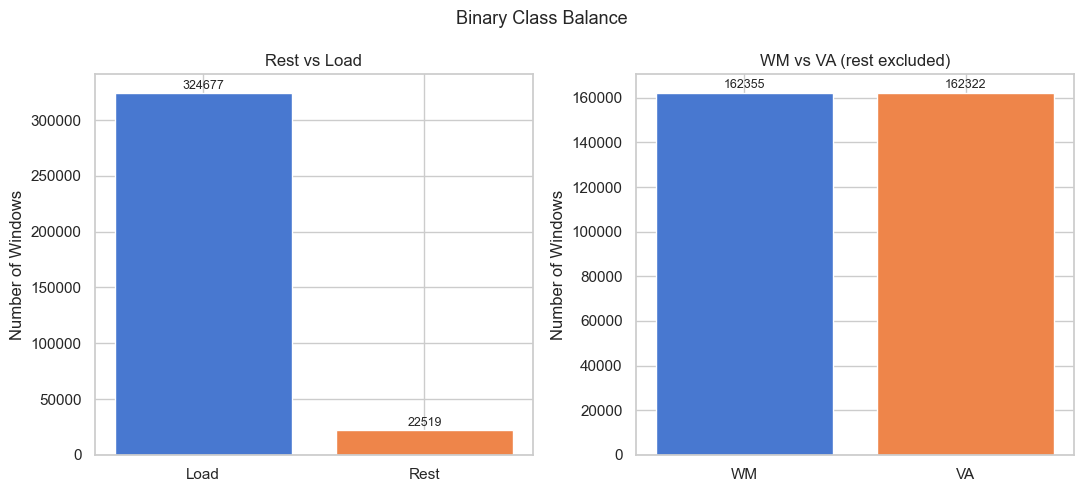

Saved: results/exploration/class_balance_binary.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Rest vs Load ---
rest_load = df['label'].map(lambda x: 'Rest' if x == 0 else 'Load').value_counts()
axes[0].bar(rest_load.index, rest_load.values, color=sns.color_palette('muted', 2))
for bar, val in zip(axes[0].patches, rest_load.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Rest vs Load')
axes[0].set_ylabel('Number of Windows')

# --- WM vs VA (exclude rest) ---
wm_va = df[df['label'] != 0]['label'].map(
    lambda x: 'WM' if x <= 3 else 'VA'
).value_counts()
axes[1].bar(wm_va.index, wm_va.values, color=sns.color_palette('muted', 2))
for bar, val in zip(axes[1].patches, wm_va.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[1].set_title('WM vs VA (rest excluded)')
axes[1].set_ylabel('Number of Windows')

plt.suptitle('Binary Class Balance', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'class_balance_binary.png', dpi=150)
plt.show()
print('Saved: results/exploration/class_balance_binary.png')

## 6. Feature Distributions by State

Box plots show how each eye-tracking feature varies across cognitive-load states.
Features examined:
- **IPAS** — Index of Pupillary Activity (short-term)
- **LHIPA** — Low/High Index of Pupillary Activity
- **fixation_durations** — mean fixation length per window
- **blink_rate** — blinks per window
- **saccade_speeds** — mean saccade velocity per window

Features that separate well across states are likely to be informative predictors.

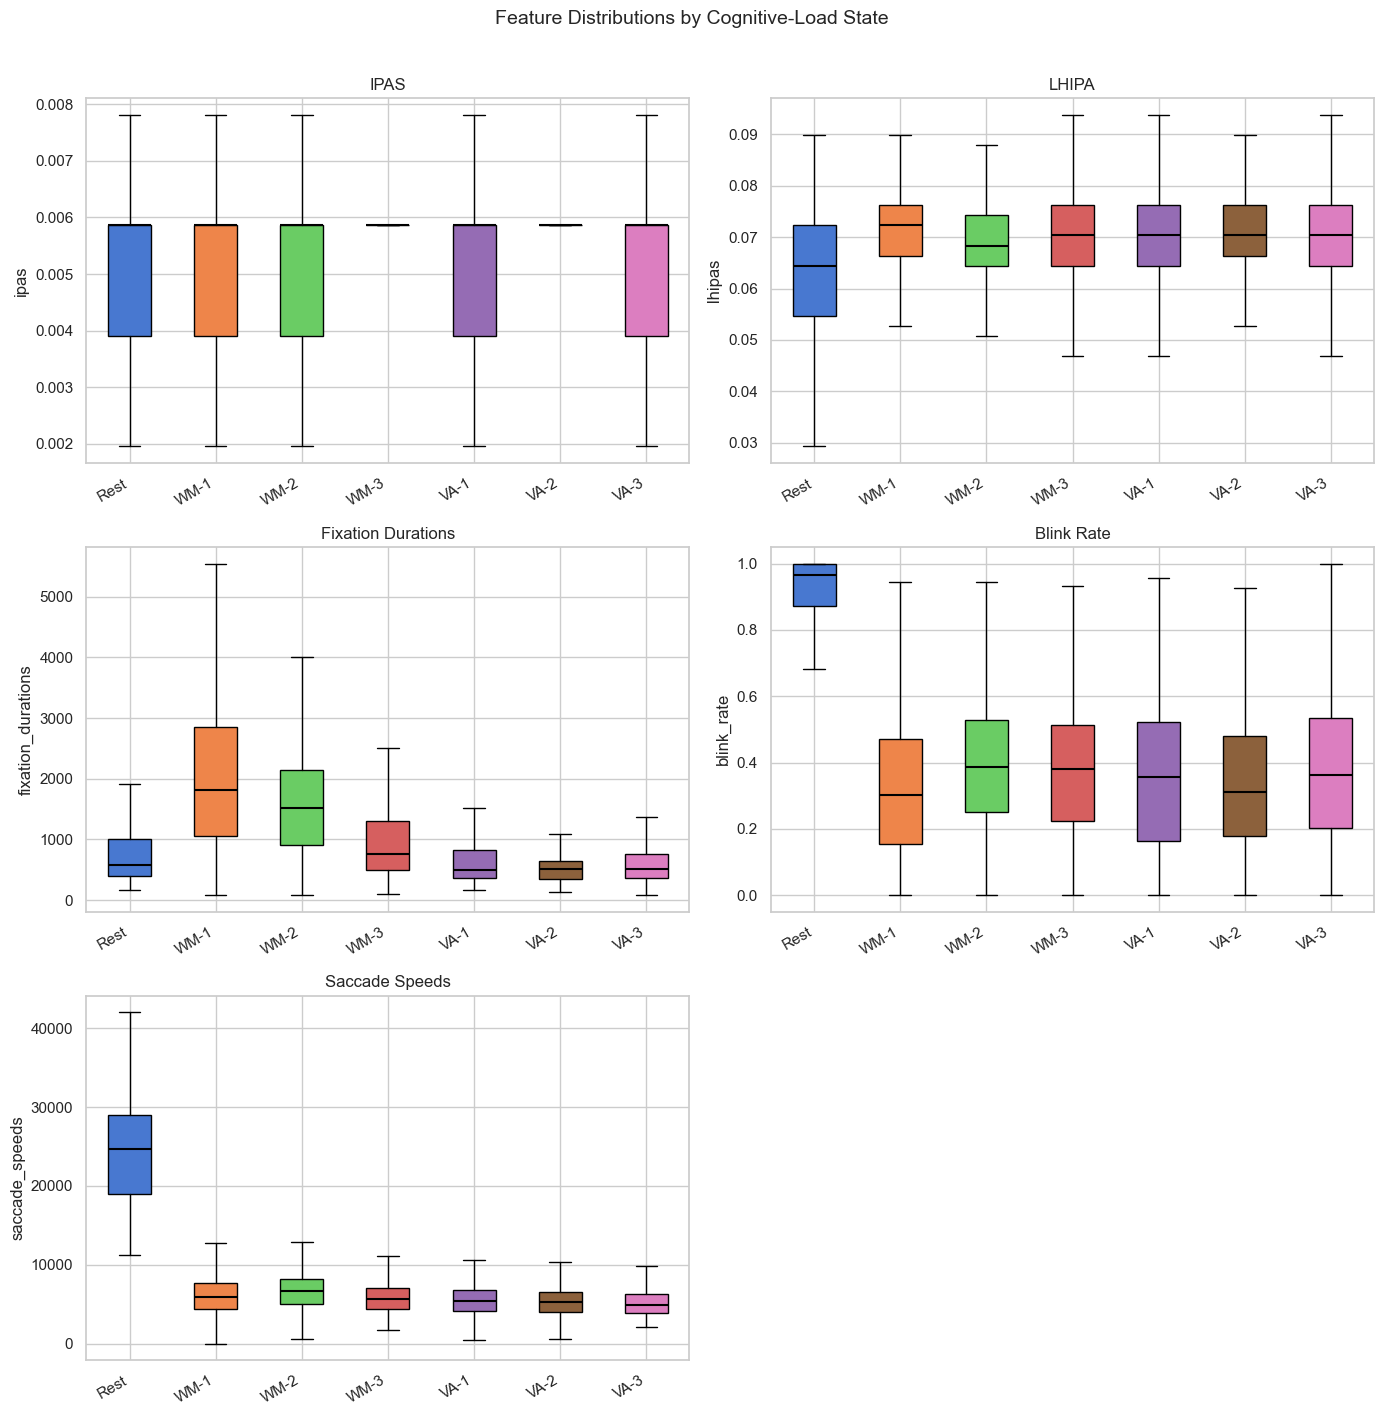

Saved: results/exploration/feature_distributions_by_state.png


In [6]:
features = ['ipas', 'lhipas', 'fixation_durations', 'blink_rate', 'saccade_speeds']
feature_titles = {
    'ipas': 'IPAS',
    'lhipas': 'LHIPA',
    'fixation_durations': 'Fixation Durations',
    'blink_rate': 'Blink Rate',
    'saccade_speeds': 'Saccade Speeds'
}

state_order = list(range(7))
tick_labels = [state_labels[s] for s in state_order]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes_flat = axes.flatten()

for i, feat in enumerate(features):
    ax = axes_flat[i]
    data_by_state = [df.loc[df['label'] == s, feat].dropna().values for s in state_order]
    bp = ax.boxplot(data_by_state, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=1.5))
    colors = sns.color_palette('muted', len(state_order))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right')
    ax.set_title(feature_titles[feat])
    ax.set_ylabel(feat)

# hide the unused 6th subplot
axes_flat[-1].set_visible(False)

plt.suptitle('Feature Distributions by Cognitive-Load State', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'feature_distributions_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/exploration/feature_distributions_by_state.png')

## Summary

- Data loaded from `data/features/features_512_511.pkl` — **347,196 windows × 18 columns**.
- Missing-value check completed.
- Class-balance plots saved for all 7 states and both binary splits.
- Box plots of 5 key features saved, showing per-state distributions.

Next step: feature selection / modelling (`02_modelling.ipynb`).